In [15]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
import src.analysis as an
FONTSIZE = 16


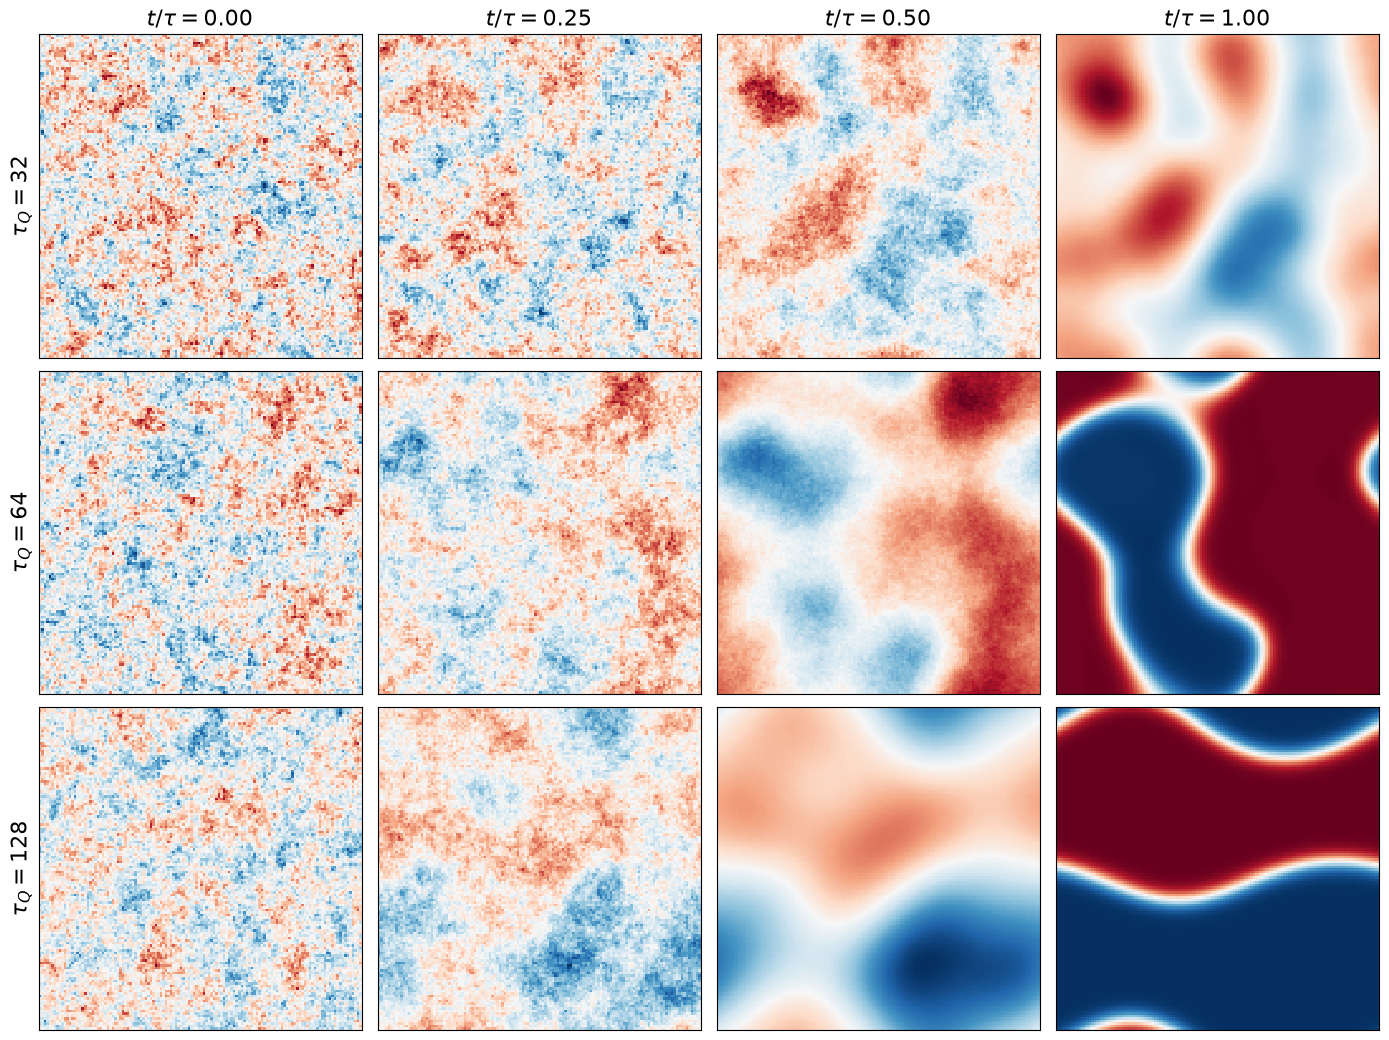

In [3]:
# ---- inputs ----
TAUS     = [32, 64, 128]
T_FRACS  = [0.0, 0.25, 0.5, 1.0]    # times to show, in units of tau (1.0 = end of quench)
SAMPLE   = 0
FONTSIZE = 16

fig, axes = plt.subplots(len(TAUS), len(T_FRACS),
                         figsize=(3.5 * len(T_FRACS), 3.5 * len(TAUS)), squeeze=False)

for row, tau in enumerate(TAUS):
    d = an.load_chunk(tau)
    for col, frac in enumerate(T_FRACS):
        snaps_t, t_used = an.snapshot_at(d, frac * tau)   # nearest stored time, all samples
        f = snaps_t[SAMPLE]
        v = np.abs(f).max()                               # per-panel symmetric scale
        ax = axes[row, col]
        ax.imshow(f, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(rf"$t/\tau = {t_used / tau:.2f}$", fontsize=FONTSIZE)
        if col == 0:
            ax.set_ylabel(rf"$\tau_Q = {tau}$", fontsize=FONTSIZE)

plt.tight_layout()
#plt.savefig("../figures/2d/evolution_vs_tau.png", dpi=150)
plt.show()

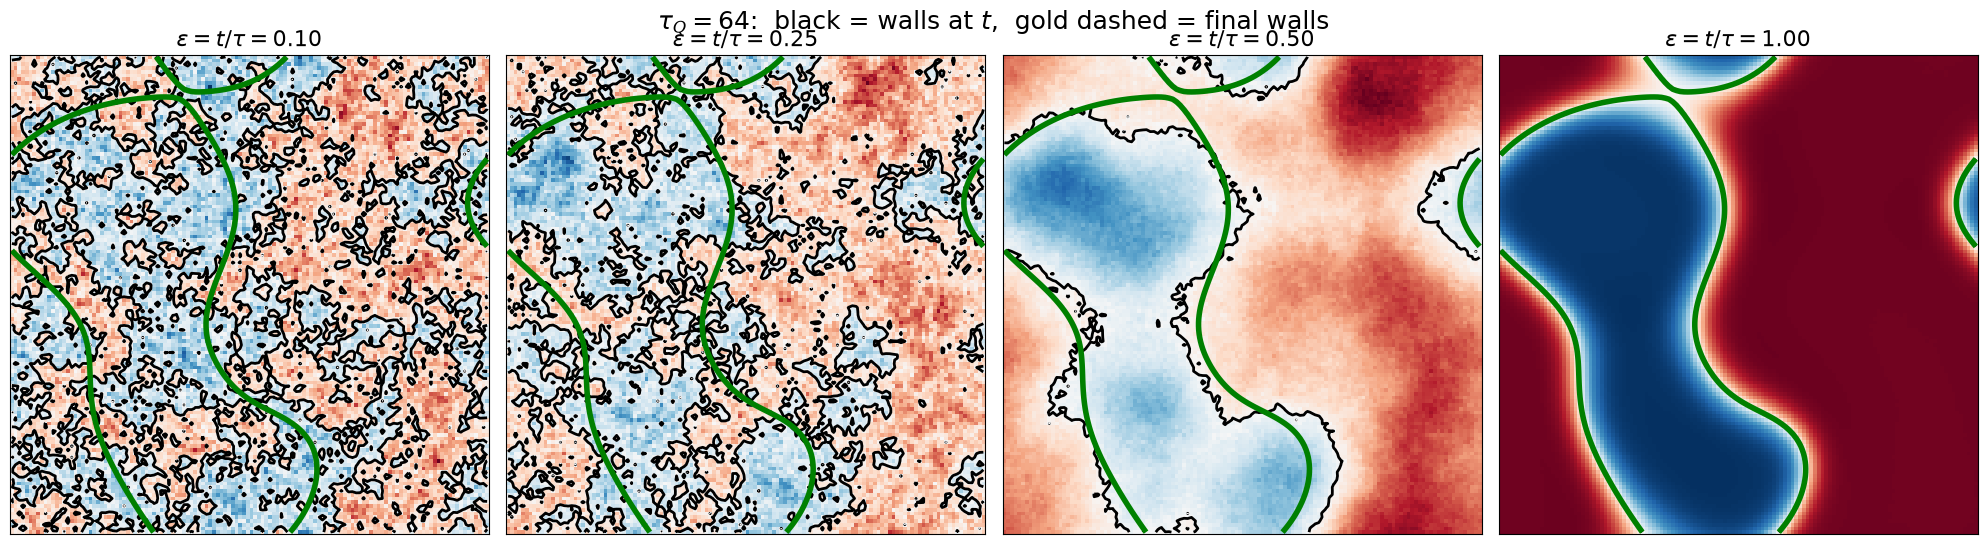

tau=   4  wall= 3989.4 ±  21.9   ell= 1.03   xi_hat= 1.68   (n=50)
tau=   6  wall= 3273.7 ±  22.2   ell= 1.25   xi_hat= 1.86   (n=50)
tau=   9  wall= 2320.1 ±  27.0   ell= 1.77   xi_hat= 2.06   (n=50)
tau=  13  wall= 1292.2 ±  24.0   ell= 3.17   xi_hat= 2.26   (n=50)
tau=  20  wall=  523.3 ±  11.8   ell= 7.83   xi_hat= 2.51   (n=50)
tau=  32  wall=  285.5 ±   7.5   ell=14.34   xi_hat= 2.83   (n=50)
tau=  64  wall=  195.0 ±   7.0   ell=21.01   xi_hat= 3.36   (n=50)
tau= 128  wall=  130.8 ±   9.1   ell=31.32   xi_hat= 4.00   (n=50)
tau= 256  wall=   49.2 ±   8.2   ell=83.29   xi_hat= 4.76   (n=50)

fitted slope (tau >= 9) = -1.061    KZ prediction = -0.250


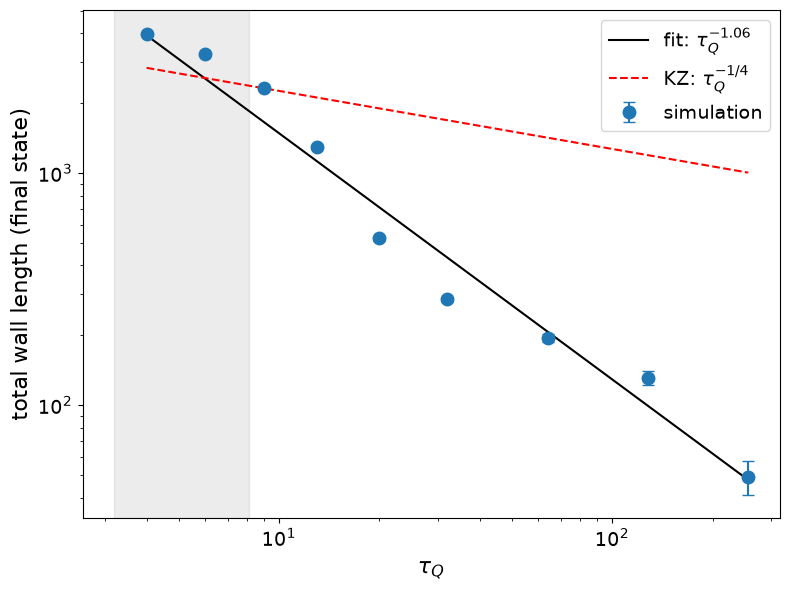

In [11]:
# ---- inputs ----
TAUS     = [4, 6, 9, 13, 20, 32, 64, 128, 256]   # missing chunks are skipped
FIT_MIN  = 9                                     # fit only tau >= FIT_MIN (small tau: xi_hat ~ lattice spacing)
DX       = 0.5
ETA      = 1.0
FONTSIZE = 16

taus, mean, err = [], [], []
for tau in TAUS:
    try:
        d = an.load_chunk(tau)                   # chunk 0 only
    except FileNotFoundError:
        print(f"tau={tau:4d}  no data, skipped")
        continue
    w = an.wall_length(d["phi_final"], dx=DX)    # one value per sample, physical units
    taus.append(tau)
    mean.append(w.mean())
    err.append(w.std() / np.sqrt(len(w)))
    N = int(d["N"])
    ell    = (N * DX)**2 / w.mean()              # domain size = area / wall length
    xi_hat = np.sqrt(2) * (tau / (2 * ETA))**0.25
    print(f"tau={tau:4d}  wall={w.mean():7.1f} ± {err[-1]:5.1f}   ell={ell:5.2f}   xi_hat={xi_hat:5.2f}   (n={len(w)})")

taus, mean, err = np.array(taus), np.array(mean), np.array(err)

# fit wall length ~ tau^slope in the scaling regime; KZ predicts -1/4
fit = taus >= FIT_MIN
slope, icpt = np.polyfit(np.log(taus[fit]), np.log(mean[fit]), 1)
print(f"\nfitted slope (tau >= {FIT_MIN}) = {slope:.3f}    KZ prediction = -0.250")

# ---- plot ----
tau_line = np.logspace(np.log10(taus.min()), np.log10(taus.max()), 50)
ref = mean[fit][0] * (tau_line / taus[fit][0])**(-0.25)     # KZ line through first fitted point

plt.figure(figsize=(8, 6))
plt.errorbar(taus, mean, yerr=err, fmt="o", ms=9, capsize=4, label="simulation")
plt.plot(tau_line, np.exp(icpt) * tau_line**slope, "k-", lw=1.5, label=rf"fit: $\tau_Q^{{{slope:.2f}}}$")
plt.plot(tau_line, ref, "r--", lw=1.5, label=r"KZ: $\tau_Q^{-1/4}$")
plt.axvspan(taus.min() * 0.8, FIT_MIN * 0.9, color="grey", alpha=0.15)   # excluded from fit
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\tau_Q$", fontsize=FONTSIZE)
plt.ylabel("total wall length (final state)", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.savefig("../figures/2d/kz_scaling.png", dpi=150)
plt.show()

tau=   9  t=   8.6 (C*t_hat=   8.5)  ell= 1.59  xi_hat= 2.06  ell/xi_hat=0.77
tau=  13  t=  10.4 (C*t_hat=  10.2)  ell= 1.78  xi_hat= 2.26  ell/xi_hat=0.79
tau=  20  t=  13.0 (C*t_hat=  12.6)  ell= 1.85  xi_hat= 2.51  ell/xi_hat=0.74
tau=  32  t=  16.0 (C*t_hat=  16.0)  ell= 1.92  xi_hat= 2.83  ell/xi_hat=0.68
tau=  64  t=  22.4 (C*t_hat=  22.6)  ell= 1.97  xi_hat= 3.36  ell/xi_hat=0.58
tau= 128  t=  32.0 (C*t_hat=  32.0)  ell= 2.10  xi_hat= 4.00  ell/xi_hat=0.53

fitted slope = 0.090    KZ prediction = +0.250


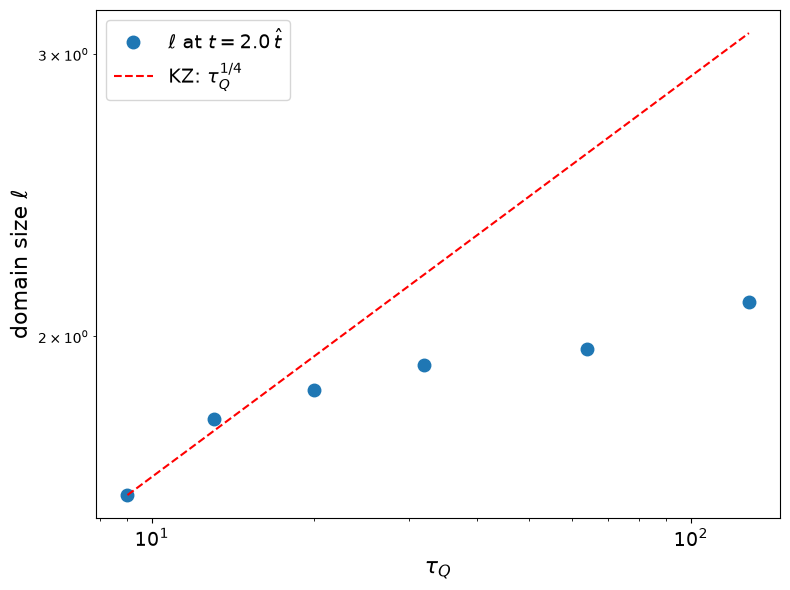

In [12]:
# ---- inputs ----
TAUS     = [9, 13, 20, 32, 64, 128]
C        = 2.0          # measure at t = C * t_hat (try 2 and 3)
DX       = 0.5
ETA      = 1.0
FONTSIZE = 16

taus, ell, ratio = [], [], []
for tau in TAUS:
    d = an.load_chunk(tau)
    N = int(d["N"])
    t_hat  = np.sqrt(2 * ETA * tau)
    xi_hat = np.sqrt(2) * (tau / (2 * ETA))**0.25
    X, t_used = an.snapshot_at(d, C * t_hat)            # nearest stored snapshot
    w = an.wall_length(X, dx=DX).mean()
    taus.append(tau); ell.append((N * DX)**2 / w); ratio.append(ell[-1] / xi_hat)
    print(f"tau={tau:4d}  t={t_used:6.1f} (C*t_hat={C*t_hat:6.1f})  ell={ell[-1]:5.2f}  xi_hat={xi_hat:5.2f}  ell/xi_hat={ratio[-1]:.2f}")

taus, ell = np.array(taus), np.array(ell)
slope = np.polyfit(np.log(taus), np.log(ell), 1)[0]
print(f"\nfitted slope = {slope:.3f}    KZ prediction = +0.250")

plt.figure(figsize=(8, 6))
plt.plot(taus, ell, "o", ms=9, label=rf"$\ell$ at $t = {C}\,\hat t$")
plt.plot(taus, ell[0] * (taus / taus[0])**0.25, "r--", lw=1.5, label=r"KZ: $\tau_Q^{1/4}$")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\tau_Q$", fontsize=FONTSIZE)
plt.ylabel(r"domain size $\ell$", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.show()

In [13]:
# ---- inputs ----
TAUS  = [9, 13, 20, 32, 64, 128]
CS    = [2, 3, 4, 6]
DX, ETA = 0.5, 1.0

print("ell / xi_hat at t = C * t_hat")
print(f"{'tau':>5} " + " ".join(f"{'C='+str(C):>7}" for C in CS))
for tau in TAUS:
    d = an.load_chunk(tau)
    N = int(d["N"])
    t_hat  = np.sqrt(2 * ETA * tau)
    xi_hat = np.sqrt(2) * (tau / (2 * ETA))**0.25
    row = []
    for C in CS:
        X, _ = an.snapshot_at(d, C * t_hat)
        ell  = (N * DX)**2 / an.wall_length(X, dx=DX).mean()
        row.append(ell / xi_hat)
    print(f"{tau:>5} " + " ".join(f"{v:7.2f}" for v in row))

ell / xi_hat at t = C * t_hat
  tau     C=2     C=3     C=4     C=6
    9    0.77    0.86    0.86    0.86
   13    0.79    1.40    1.40    1.40
   20    0.74    2.58    3.11    3.11
   32    0.68    2.77    5.07    5.07
   64    0.58    3.22    5.23    6.24
  128    0.53    1.93    5.66    6.89


tau=   8  t_f=  23.8  t_f/t_hat=5.95  ell= 11.33  xi_hat= 2.00  ell/xi_hat=5.66
tau=  16  t_f=  31.8  t_f/t_hat=5.62  ell= 15.59  xi_hat= 2.38  ell/xi_hat=6.56
tau=  32  t_f=  42.8  t_f/t_hat=5.35  ell= 19.26  xi_hat= 2.83  ell/xi_hat=6.81

fitted slope = 0.383    KZ prediction = +0.250


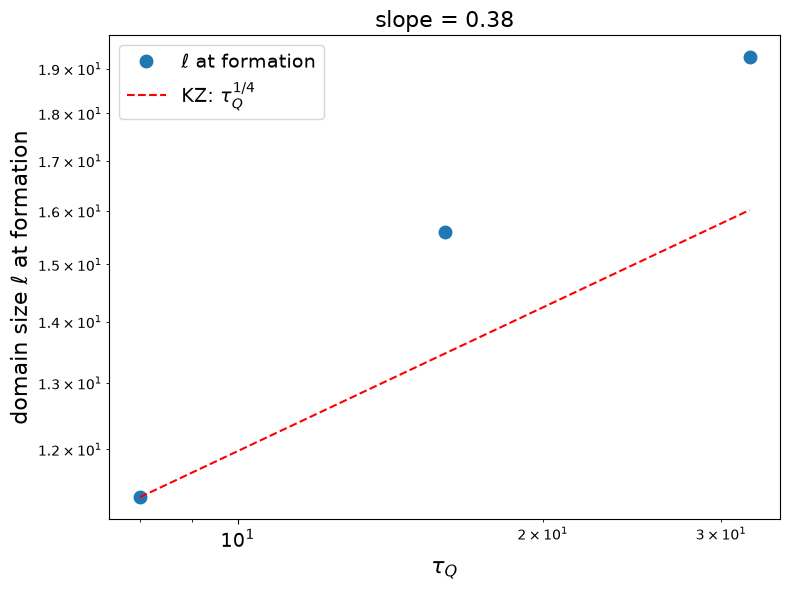

In [ ]:
# ---- inputs ----
import src.kz_2d as kz2
TAUS     = [8, 16, 32]
N        = 128          # bigger box so large tau isn't finite-size limited
N_REAL   = 6           # samples per tau
FRAC     = 0.5          # formation: phi_rms reaches FRAC * sqrt(eps)
SEED     = 0
FONTSIZE = 16

kz2.dx, kz2.eta, kz2.theta = 0.5, 1.0, 1e-8
kz2.EPS_I, kz2.EPS_F = -1.5, 1.0
kz2.N = N
kz2.EPS_I, kz2.EPS_F = -1.5, 3.0       # ramp further so every tau reaches formation
taus, ell, t_f = [], [], []
for tau in TAUS:
    kz2.TAU = float(tau)
    t_hist, dt = kz2.make_time_grid(n_steps=int(round(10 * (kz2.EPS_F - kz2.EPS_I) * tau)))   # keeps dt = 0.1
    t0, t1 = t_hist[0], t_hist[-1]

    rng = np.random.default_rng(SEED)
    phi = np.zeros((N_REAL, N, N))
    pi  = np.zeros((N_REAL, N, N))
    amp = np.sqrt(2 * kz2.eta * kz2.theta * dt / kz2.dx**2)

    # evolve until the field reaches FRAC of its equilibrium amplitude, then measure walls
    for step in range(1, len(t_hist)):
        phi, pi = kz2.rk4_step(phi, pi, t_hist[step - 1], dt, t0, t1)
        pi += amp * rng.standard_normal(phi.shape)
        t   = t_hist[step]
        eps = t / tau
        if eps > 0 and np.sqrt((phi**2).mean()) >= FRAC * np.sqrt(eps):
            break

    w = kz2.wall_length(phi).mean()
    taus.append(tau)
    ell.append((N * kz2.dx)**2 / w)
    t_f.append(t)
    t_hat  = np.sqrt(2 * kz2.eta * tau)
    xi_hat = np.sqrt(2) * (tau / (2 * kz2.eta))**0.25
    print(f"tau={tau:4d}  t_f={t:6.1f}  t_f/t_hat={t / t_hat:4.2f}  "
          f"ell={ell[-1]:6.2f}  xi_hat={xi_hat:5.2f}  ell/xi_hat={ell[-1] / xi_hat:4.2f}")

taus, ell = np.array(taus), np.array(ell)
slope = np.polyfit(np.log(taus), np.log(ell), 1)[0]
print(f"\nfitted slope = {slope:.3f}    KZ prediction = +0.250")

# ---- plot ----
plt.figure(figsize=(8, 6))
plt.plot(taus, ell, "o", ms=9, label=r"$\ell$ at formation")
plt.plot(taus, ell[0] * (taus / taus[0])**0.25, "r--", lw=1.5, label=r"KZ: $\tau_Q^{1/4}$")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\tau_Q$", fontsize=FONTSIZE)
plt.ylabel(r"domain size $\ell$ at formation", fontsize=FONTSIZE)
plt.title(rf"slope = {slope:.2f}", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.savefig("../figures/2d/kz_scaling.png", dpi=150)
plt.show()